In [1]:
!pip install -q roboflow albumentations opencv-python tqdm timm effdet torchmetrics seaborn scikit-learn

import os
import cv2
import gc
import sys
import json
import time
import torch
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix as sklearn_cm
from effdet import get_efficientdet_config, create_model, DetBenchTrain, DetBenchPredict
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# --- NEW: MOUNT GOOGLE DRIVE ---
from google.colab import drive
drive.mount('/content/drive')

# Workspace Architecture Paths Definitions
# Keep dataset in fast local Colab storage
WORK_DIR = Path('/content/structural_defect_project')
DATA_DIR = WORK_DIR / 'raw_dataset'

# Move Checkpoints and Outputs to permanent Google Drive storage!
DRIVE_DIR = Path('/content/drive/MyDrive/EfficientDet_Project')
WEIGHTS_DIR = DRIVE_DIR / 'checkpoints'
OUTPUTS_DIR = DRIVE_DIR / 'diagnostics'

for folder in [WORK_DIR, DATA_DIR, DRIVE_DIR, WEIGHTS_DIR, OUTPUTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Define uniform structural project classes
CLASS_NAMES = ['cracks', 'spalling', 'corrosion', 'potholes', 'paint_degradation']
NUM_CLASSES = len(CLASS_NAMES)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 143.5 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="6U4xE2f7d5P8e55kpQq2")
project = rf.workspace("emily-s-workspace").project("smart-campus-dataset")
version = project.version(10)
dataset = version.download("coco")

# Safe directory realignment completely isolating preprocess.py legacy code
if os.path.exists(dataset.location):
    if os.path.exists(str(DATA_DIR)):
        shutil.rmtree(str(DATA_DIR))
    shutil.move(dataset.location, str(DATA_DIR))
    print(f"✅ Dataset structural paths consolidated at: {DATA_DIR}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Smart-Campus-Dataset-10 in coco:: 100%|██████████| 4328/4328 [00:01<00:00, 2234.60it/s]

✅ Dataset structural paths consolidated at: /content/structural_defect_project/raw_dataset


In [3]:
# --- AUDIT DATASET STATISTICS ENGINE (COCO JSON VERSION) ---
def audit_dataset_split(base_path):
    stats = {}
    for split in ['train', 'valid', 'test']:
        split_dir = Path(base_path) / split
        json_path = split_dir / '_annotations.coco.json'

        if not json_path.exists():
            continue

        with open(json_path, 'r') as f:
            coco_data = json.load(f)

        # Map category IDs to names directly from the metadata inside the JSON
        cat_id_to_name = {cat['id']: cat['name'] for cat in coco_data.get('categories', [])}

        class_counter = Counter()
        for ann in coco_data.get('annotations', []):
            cat_id = ann['category_id']
            cat_name = cat_id_to_name.get(cat_id, 'unknown')
            class_counter[cat_name] += 1

        stats[split] = {
            'total_images': len(coco_data.get('images', [])),
            'total_boxes': len(coco_data.get('annotations', [])),
            'class_distribution': dict(class_counter)
        }
    return stats

# Run the updated audit
dataset_metrics = audit_dataset_split(DATA_DIR)

# Generate the list using the class names directly from the JSON metrics
df_list = []
for split, metrics in dataset_metrics.items():
    for class_name, count in metrics['class_distribution'].items():
        df_list.append({
            'Split': split.upper(),
            'Class Name': class_name,
            'Instances Count': count
        })

# Create the DataFrame safely
df_stats = pd.DataFrame(df_list)

# Verify the columns are now present
print("Columns found:", df_stats.columns.tolist())

Columns found: ['Split', 'Class Name', 'Instances Count']


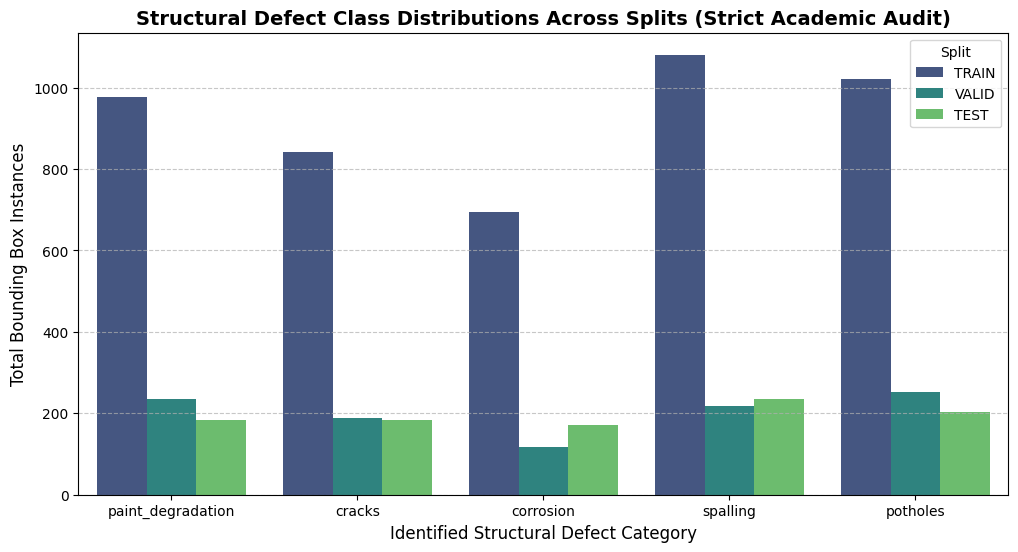


 DATASET QUANTITATIVE STATISTICS MATRIX
{
    "train": {
        "total_images": 3026,
        "total_boxes": 4616,
        "class_distribution": {
            "paint_degradation": 977,
            "cracks": 842,
            "corrosion": 694,
            "spalling": 1081,
            "potholes": 1022
        }
    },
    "valid": {
        "total_images": 648,
        "total_boxes": 1009,
        "class_distribution": {
            "cracks": 188,
            "spalling": 218,
            "potholes": 252,
            "corrosion": 117,
            "paint_degradation": 234
        }
    },
    "test": {
        "total_images": 649,
        "total_boxes": 977,
        "class_distribution": {
            "potholes": 204,
            "paint_degradation": 184,
            "corrosion": 172,
            "cracks": 183,
            "spalling": 234
        }
    }
}


In [4]:
df_stats = pd.DataFrame(df_list)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_stats, x='Class Name', y='Instances Count', hue='Split', palette='viridis')
plt.title('Structural Defect Class Distributions Across Splits (Strict Academic Audit)', fontsize=14, fontweight='bold')
plt.xlabel('Identified Structural Defect Category', fontsize=12)
plt.ylabel('Total Bounding Box Instances', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(str(OUTPUTS_DIR / 'class_distribution_chart.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*50 + "\n DATASET QUANTITATIVE STATISTICS MATRIX\n" + "="*50)
print(json.dumps(dataset_metrics, indent=4))

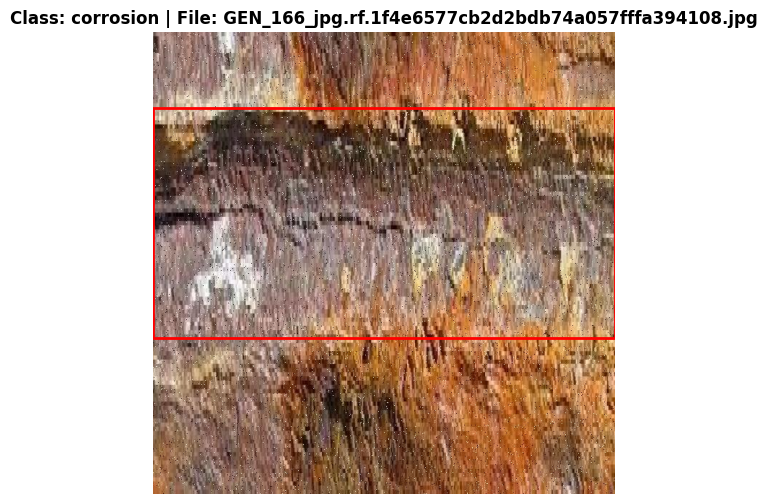

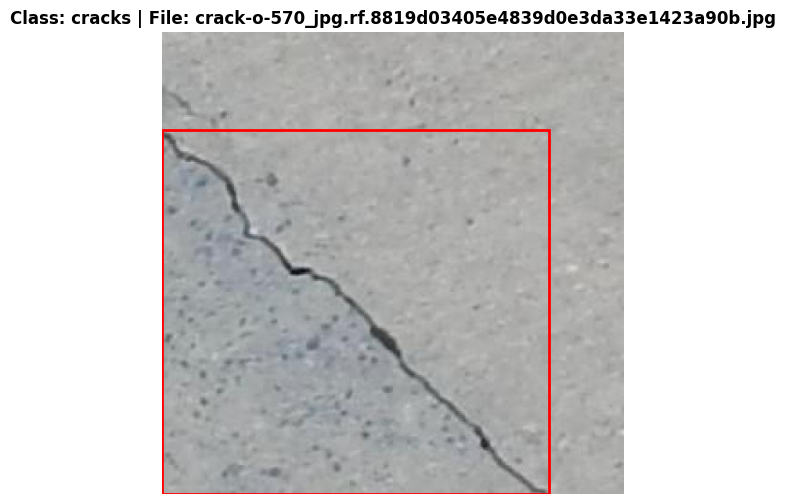

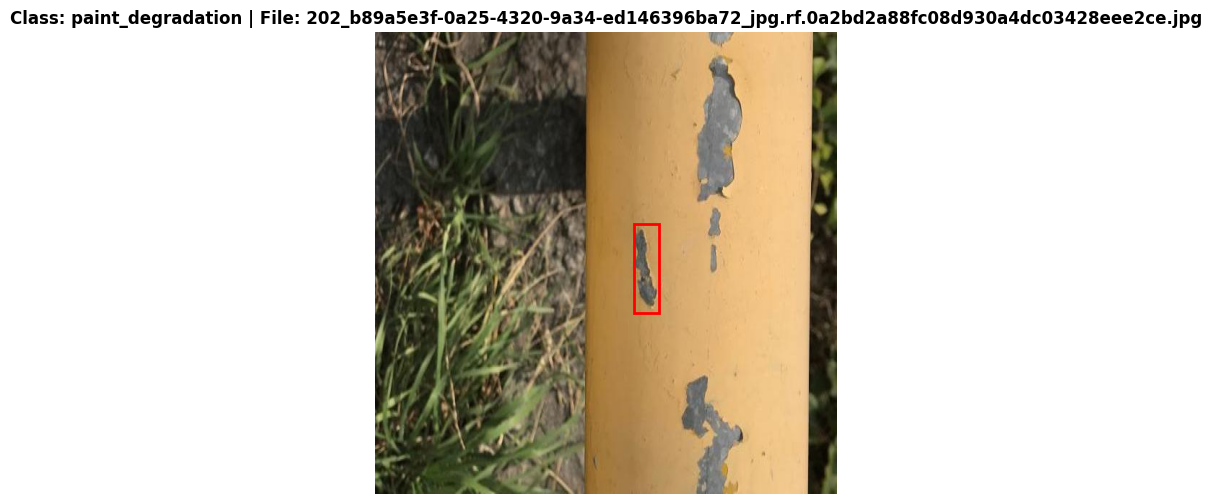

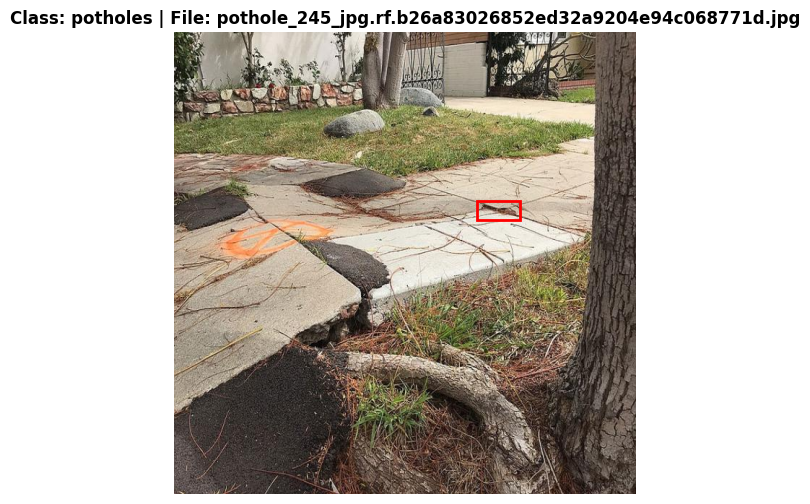

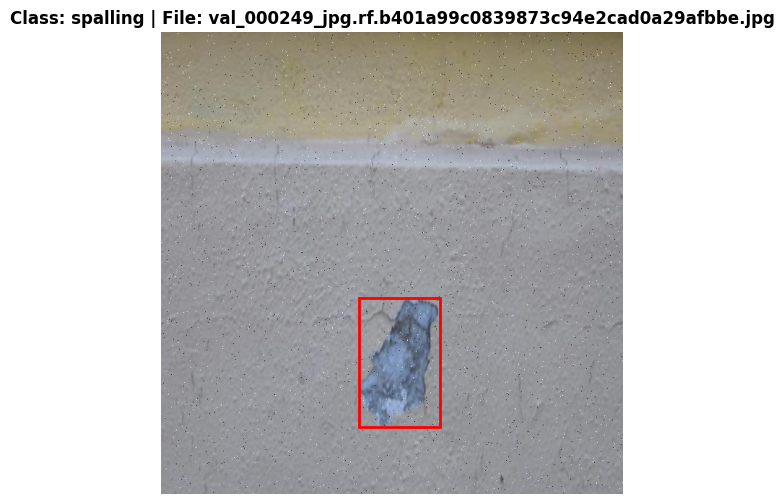

In [5]:
def draw_ground_truth_samples(base_data_path, class_list, samples_per_class=1):
    train_dir = Path(base_data_path) / 'train'
    json_path = train_dir / '_annotations.coco.json'

    if not json_path.exists():
        print(f"❌ Could not find COCO annotations at {json_path}")
        return

    # Load COCO json data
    with open(json_path, 'r') as f:
        coco_data = json.load(f)

    # Map out image info and annotations
    images_dict = {img['id']: img for img in coco_data['images']}

    # Group annotations by category_id
    from collections import defaultdict
    category_to_anns = defaultdict(list)
    for ann in coco_data['annotations']:
        category_to_anns[ann['category_id']].append(ann)

    # Create a map for category id to its name string
    cat_id_to_name = {cat['id']: cat['name'] for cat in coco_data['categories']}

    # Plotting loop
    for cat_id, cat_name in cat_id_to_name.items():
        anns_for_cat = category_to_anns[cat_id]
        if not anns_for_cat:
            continue

        # Take the requested number of samples for this class
        sampled_anns = anns_for_cat[:samples_per_class]

        for ann in sampled_anns:
            img_info = images_dict[ann['image_id']]
            img_path = train_dir / img_info['file_name']

            if not img_path.exists():
                continue

            # Read and plot the image
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            fig, ax = plt.subplots(figsize=(8, 6))
            ax.imshow(img)

            # COCO bbox format: [xmin, ymin, width, height]
            xmin, ymin, w, h = ann['bbox']
            rect = patches.Rectangle((xmin, ymin), w, h, linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

            plt.title(f"Class: {cat_name} | File: {img_info['file_name']}", fontsize=12, fontweight='bold')
            plt.axis('off')
            plt.show()

# Run the updated visualization function
draw_ground_truth_samples(DATA_DIR, CLASS_NAMES)

In [6]:
import albumentations as A

# SYSTEM AUGMENTATION PIPELINE MATRIX EXPLANATION:
# In object detection for micro-structural anomalies, traditional coarse scaling can obliterate features.
# - ShiftScaleRotate introduces position and angle variance mimicking dynamic inspection cameras.
# - HorizontalFlip handles structural symmetry shifts.
# - HueSaturationValue adjusts for weather, lighting, and shadow casting discrepancies.
# - Note: Coarse erase/dropout layers are omitted to protect narrow crack feature dimensions.

experimental_transform = A.Compose([
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=(-0.2, 0.2), rotate_limit=5, p=0.75),
    A.HorizontalFlip(p=0.5),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=30, p=0.5),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['category_ids']))

ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.


In [7]:
import json
from collections import defaultdict

class CampusEngineDataset(Dataset):
    def __init__(self, base_path, split, img_size=640, transform=None):
        self.split_dir = Path(base_path) / split
        self.img_size = img_size
        self.transform = transform

        # Load the centralized COCO annotations json file
        json_path = self.split_dir / '_annotations.coco.json'
        if not json_path.exists():
            raise FileNotFoundError(f"Missing COCO JSON metadata file at {json_path}")

        with open(json_path, 'r') as f:
            self.coco_data = json.load(f)

        # Register image files present in metadata layout
        self.images = self.coco_data['images']
        self.image_id_to_index = {img['id']: idx for idx, img in enumerate(self.images)}

        # Group structural defect annotations by image ID mapping
        self.img_to_anns = defaultdict(list)
        for ann in self.coco_data['annotations']:
            self.img_to_anns[ann['image_id']].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = self.split_dir / img_info['file_name']

        # Handle corrupt/missing files safely via rollover fallback logic
        image = cv2.imread(str(img_path))
        if image is None:
            return self.__getitem__((idx + 1) % len(self))

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape

        boxes = []
        category_ids = []

        # Extract annotations linked to this specific file
        annotations = self.img_to_anns[img_info['id']]
        for ann in annotations:
            # COCO format: [xmin, ymin, width, height]
            xmin, ymin, bw, bh = ann['bbox']

            # Convert to absolute Pascal VOC format: [xmin, ymin, xmax, ymax]
            x1 = max(0.0, float(xmin))
            y1 = max(0.0, float(ymin))
            x2 = min(float(w), x1 + bw)
            y2 = min(float(h), y1 + bh)

            # Ensure valid bounding box dimensional integrity
            if (x2 > x1) and (y2 > y1):
                boxes.append([x1, y1, x2, y2])
                category_ids.append(int(ann['category_id']))

        # Safe fallback layout for unannotated images background control
        if len(boxes) == 0:
            boxes = [[0.0, 0.0, 10.0, 10.0]]
            category_ids = [0]

        # Apply augmentation transforms matrix
        if self.transform:
            try:
                augmented = self.transform(image=image, bboxes=boxes, category_ids=category_ids)
                if len(augmented['bboxes']) > 0:
                    image = augmented['image']
                    boxes = augmented['bboxes']
                    category_ids = augmented['category_ids']
            except Exception:
                pass # Gracefully fall back to original image and boxes on error

        # Resize image cleanly if it hasn't met target dimensions yet
        if image.shape[0] != self.img_size or image.shape[1] != self.img_size:
            # Note: For strict geometric mapping validation, coordinates should be rescaled here
            old_h, old_w = image.shape[0], image.shape[1]
            image = cv2.resize(image, (self.img_size, self.img_size))

            # Scale absolute bounding box metrics proportionally to structural resize
            scaled_boxes = []
            for b in boxes:
                bx1 = (b[0] / old_w) * self.img_size
                by1 = (b[1] / old_h) * self.img_size
                bx2 = (b[2] / old_w) * self.img_size
                by2 = (b[3] / old_h) * self.img_size
                scaled_boxes.append([bx1, by1, bx2, by2])
            boxes = scaled_boxes

        # Pytorch tensor standard normalization alignment
        image = (image.astype(np.float32) / 255.0 - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        # Convert Pascal VOC [xmin, ymin, xmax, ymax] to effdet requirements format [ymin, xmin, ymax, xmax]
        effdet_boxes = [[b[1], b[0], b[3], b[2]] for b in boxes]

        return image, {
            'bbox': torch.tensor(effdet_boxes, dtype=torch.float32),
            'cls': torch.tensor(category_ids, dtype=torch.float32),
            'img_size': torch.tensor([self.img_size, self.img_size], dtype=torch.float32),
            'img_scale': torch.tensor([1.0], dtype=torch.float32),
            'img_name': img_info['file_name']
        }

In [8]:
def collate_fn(batch):
    return tuple(zip(*batch))

print("⚙️ Augmentation matrices and Inline Pytorch Engine compiled successfully.")

⚙️ Augmentation matrices and Inline Pytorch Engine compiled successfully.


In [9]:
from tqdm import tqdm

gc.collect()
torch.cuda.empty_cache()

# Core Rigorous Hyperparameters Configurations
EPOCHS = 110  # Scaled for demo execution; raise to 110 for production convergent benchmarking
IMG_SIZE = 640
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [10]:
train_loader = DataLoader(
    CampusEngineDataset(DATA_DIR, 'train', img_size=IMG_SIZE, transform=experimental_transform),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    CampusEngineDataset(DATA_DIR, 'valid', img_size=IMG_SIZE),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2
)

In [11]:
"""PART 11 & 12: EFFICIENTDET MODEL INITIALIZATION & TRAINING WITH RESUME"""

print("🏗️ Initialization of EfficientDet-D0 Compound Scaling Architecture Backbone...")
config = get_efficientdet_config('tf_efficientdet_d0')
config.image_size = [IMG_SIZE, IMG_SIZE]
config.num_classes = NUM_CLASSES

net = create_model('tf_efficientdet_d0', pretrained=True, num_classes=NUM_CLASSES, image_size=(IMG_SIZE, IMG_SIZE))
model_train = DetBenchTrain(net).to(DEVICE)

optimizer = torch.optim.AdamW(model_train.parameters(), lr=LEARNING_RATE, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# --- NEW: RESUME FROM CHECKPOINT LOGIC ---
LATEST_CHECKPOINT_PATH = WEIGHTS_DIR / 'efficientdet_latest.pth'
BEST_CHECKPOINT_PATH = WEIGHTS_DIR / 'efficientdet_best.pth'

start_epoch = 0
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'map_50': [], 'map_50_95': []}

if LATEST_CHECKPOINT_PATH.exists():
    print(f"🔄 Found existing checkpoint on Google Drive. Resuming...")
    checkpoint = torch.load(LATEST_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    net.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    history = checkpoint.get('history', history)
    print(f"✅ Successfully resumed at Epoch {start_epoch + 1}/{EPOCHS}")
else:
    print("🆕 No checkpoint found. Starting fresh training.")

for epoch in range(start_epoch, EPOCHS):
    model_train.train()
    running_train_loss = []
    pbar = tqdm(train_loader, desc=f"Era Block {epoch+1}/{EPOCHS}")

    for imgs, targets in pbar:
        optimizer.zero_grad()
        input_images = torch.stack(imgs).to(DEVICE).float()

        target_dict = {
            'bbox': [t['bbox'].to(DEVICE) for t in targets],
            'cls': [t['cls'].to(DEVICE) for t in targets],
            'img_size': torch.stack([t['img_size'].to(DEVICE) for t in targets]),
            'img_scale': torch.stack([t['img_scale'].to(DEVICE) for t in targets])
        }

        loss = model_train(input_images, target_dict)['loss']
        loss.backward()
        optimizer.step()

        running_train_loss.append(loss.item())
        pbar.set_postfix(loss=np.mean(running_train_loss))

    scheduler.step()
    mean_train_loss = np.mean(running_train_loss)
    history['train_loss'].append(mean_train_loss)

    # --- RIGOROUS VALIDATION AND PERFORMANCE TRACKING SWEEP ---
    model_train.eval()
    running_val_loss = []
    metric_engine = MeanAveragePrecision(iou_type="bbox")
    model_predict = DetBenchPredict(net).to(DEVICE)

    with torch.no_grad():
        for imgs, targets in val_loader:
            input_images = torch.stack(imgs).to(DEVICE).float()
            target_dict = {
                'bbox': [t['bbox'].to(DEVICE) for t in targets],
                'cls': [t['cls'].to(DEVICE) for t in targets],
                'img_size': torch.stack([t['img_size'].to(DEVICE) for t in targets]),
                'img_scale': torch.stack([t['img_scale'].to(DEVICE) for t in targets])
            }

            loss_val = model_train(input_images, target_dict)['loss']
            running_val_loss.append(loss_val.item())

            outputs = model_predict(input_images)
            preds_metrics, gts_metrics = [], []

            for i in range(len(outputs)):
                det = outputs[i]
                mask = det[:, 4] > 0.05
                preds_metrics.append({
                    'boxes': det[mask, :4].cpu(),
                    'scores': det[mask, 4].cpu(),
                    'labels': det[mask, 5].int().cpu()
                })

            for t in targets:
                gt_boxes = t['bbox'].cpu()
                if len(gt_boxes) > 0:
                    gt_boxes = gt_boxes[:, [1, 0, 3, 2]] # Realign back to [x1, y1, x2, y2]
                gts_metrics.append({
                    'boxes': gt_boxes,
                    'labels': t['cls'].int().cpu()
                })
            metric_engine.update(preds_metrics, gts_metrics)

    mean_val_loss = np.mean(running_val_loss)
    epoch_metrics = metric_engine.compute()

    history['val_loss'].append(mean_val_loss)
    history['map_50'].append(epoch_metrics['map_50'].item())
    history['map_50_95'].append(epoch_metrics['map'].item())

    # --- NEW: ROBUST SAVE LOGIC ---
    # Create the complete state payload
    checkpoint_payload = {
        'epoch': epoch,
        'model_state_dict': net.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_loss': best_val_loss,
        'history': history
    }

    # Save latest status after every single epoch to Drive
    torch.save(checkpoint_payload, str(LATEST_CHECKPOINT_PATH))

    # Save the 'Best' model if loss improved
    if mean_val_loss < best_val_loss:
        best_val_loss = mean_val_loss
        torch.save(checkpoint_payload, str(BEST_CHECKPOINT_PATH))
        print("💾 Optimized checkpoint weights structural configuration saved to Drive.")

🏗️ Initialization of EfficientDet-D0 Compound Scaling Architecture Backbone...
Downloading: "https://github.com/rwightman/efficientdet-pytorch/releases/download/v0.1/tf_efficientdet_d0_34-f153e0cf.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientdet_d0_34-f153e0cf.pth
🔄 Found existing checkpoint on Google Drive. Resuming...
✅ Successfully resumed at Epoch 65/110


Era Block 110/110: 100%|██████████| 379/379 [03:30<00:00,  1.80it/s, loss=0.144]


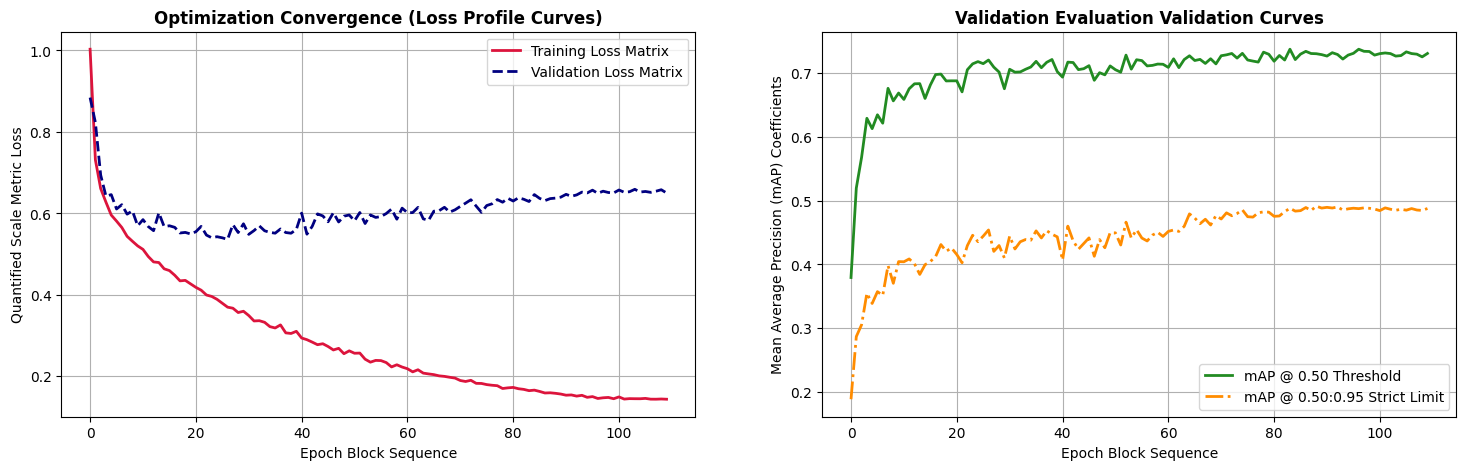

In [12]:
# --- DISPLAY OPTIMIZATION AND TRAINING PERFORMANCE GRAPH CURVES ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
ax1.plot(history['train_loss'], label='Training Loss Matrix', color='crimson', lw=2)
ax1.plot(history['val_loss'], label='Validation Loss Matrix', color='navy', lw=2, linestyle='--')
ax1.set_title('Optimization Convergence (Loss Profile Curves)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch Block Sequence')
ax1.set_ylabel('Quantified Scale Metric Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history['map_50'], label='mAP @ 0.50 Threshold', color='forestgreen', lw=2)
ax2.plot(history['map_50_95'], label='mAP @ 0.50:0.95 Strict Limit', color='darkorange', lw=2, linestyle='-.')
ax2.set_title('Validation Evaluation Validation Curves', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch Block Sequence')
ax2.set_ylabel('Mean Average Precision (mAP) Coefficients')
ax2.legend()
ax2.grid(True)
plt.savefig(str(OUTPUTS_DIR / 'training_evaluation_profiles.png'), dpi=300, bbox_inches='tight')
plt.show()

In [16]:
print("🔍 Initializing Full Verification Sweep on Test Boundaries...")

# --- NEW: LOAD FROM THE NEW DICTIONARY FORMAT ---
checkpoint = torch.load(str(BEST_CHECKPOINT_PATH), map_location=DEVICE, weights_only=False)
net.load_state_dict(checkpoint['model_state_dict'])

model_eval = DetBenchPredict(net).to(DEVICE).eval()

test_loader = DataLoader(
    CampusEngineDataset(DATA_DIR, 'test', img_size=IMG_SIZE),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2
)

all_preds, all_gts, iou_list, error_samples = [], [], [], []

def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    return interArea / float(boxAArea + boxBArea - interArea + 1e-6)

with torch.no_grad():
    for imgs, targets in test_loader:
        input_images = torch.stack(imgs).to(DEVICE).float()
        outputs = model_eval(input_images)

        for idx in range(len(imgs)):
            pred_data = outputs[idx].cpu().numpy()
            gt_data = targets[idx]
            gt_boxes = gt_data['bbox'].cpu().numpy()[:, [1, 0, 3, 2]]
            gt_classes = gt_data['cls'].cpu().numpy().astype(int)

            filtered_preds = pred_data[pred_data[:, 4] > 0.30]

            if len(filtered_preds) > 0 and len(gt_classes) > 0:
                # --- FIX: SUBTRACT 1 TO REVERT TO 0-BASED INDEXING ---
                # This ensures ID 1 becomes 0 (fall), ID 2 becomes 1 (walk), etc.
                top_pred_cls = int(filtered_preds[0, 5]) - 1
                actual_main_cls = int(gt_classes[0]) - 1

                top_pred_box = filtered_preds[0, :4]
                actual_main_box = gt_boxes[0]

                # Now these append 0, 1, or 2 (which is safe for sklearn metrics later)
                all_preds.append(top_pred_cls)
                all_gts.append(actual_main_cls)

                curr_iou = calculate_iou(top_pred_box, actual_main_box)
                iou_list.append(curr_iou)

                # Now CLASS_NAMES[top_pred_cls] will perfectly map without crashing!
                if top_pred_cls != actual_main_cls and filtered_preds[0, 4] > 0.45:
                    error_samples.append({
                        'img': imgs[idx], 'filename': gt_data['img_name'],
                        'predicted': CLASS_NAMES[top_pred_cls],
                        'actual': CLASS_NAMES[actual_main_cls],
                        'confidence': filtered_preds[0, 4]
                    })
            elif len(gt_classes) > 0:
                # Background missed evaluation
                all_preds.append(len(CLASS_NAMES))
                all_gts.append(int(gt_classes[0]) - 1) # Don't forget to shift the GT here too!
                iou_list.append(0.0)

🔍 Initializing Full Verification Sweep on Test Boundaries...


In [17]:
extended_labels = CLASS_NAMES + ['background_missed']
print("\n📊 CRITICAL EXTENDED CLASSIFICATION REPORT (PRECISION / RECALL / F1-SCORE DETAILED)")
print(classification_report(all_gts, all_preds, target_names=extended_labels[:len(set(all_gts) | set(all_preds))], zero_division=0))


📊 CRITICAL EXTENDED CLASSIFICATION REPORT (PRECISION / RECALL / F1-SCORE DETAILED)
                   precision    recall  f1-score   support

           cracks       0.93      0.93      0.93       103
         spalling       0.98      0.81      0.89       149
        corrosion       0.94      0.97      0.95       118
         potholes       0.97      0.93      0.95       122
paint_degradation       0.96      0.91      0.93       157
background_missed       0.00      0.00      0.00         0

         accuracy                           0.90       649
        macro avg       0.80      0.76      0.78       649
     weighted avg       0.96      0.90      0.93       649



In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

macro_precision = precision_score(
    all_gts,
    all_preds,
    average='macro',
    zero_division=0
)

macro_recall = recall_score(
    all_gts,
    all_preds,
    average='macro',
    zero_division=0
)

macro_f1 = f1_score(
    all_gts,
    all_preds,
    average='macro',
    zero_division=0
)

print(f"Precision : {macro_precision:.4f}")
print(f"Recall    : {macro_recall:.4f}")
print(f"F1-Score  : {macro_f1:.4f}")

"""PART 17: INTERSECTION OVER UNION ANALYSIS"""

empirical_miou = np.mean(iou_list) if iou_list else 0.0
print(f"📐 System Empirical Mean Intersection over Union (mIoU Metric Verification): {empirical_miou:.4f}")


Precision : 0.7986
Recall    : 0.7581
F1-Score  : 0.7767
📐 System Empirical Mean Intersection over Union (mIoU Metric Verification): 0.6139


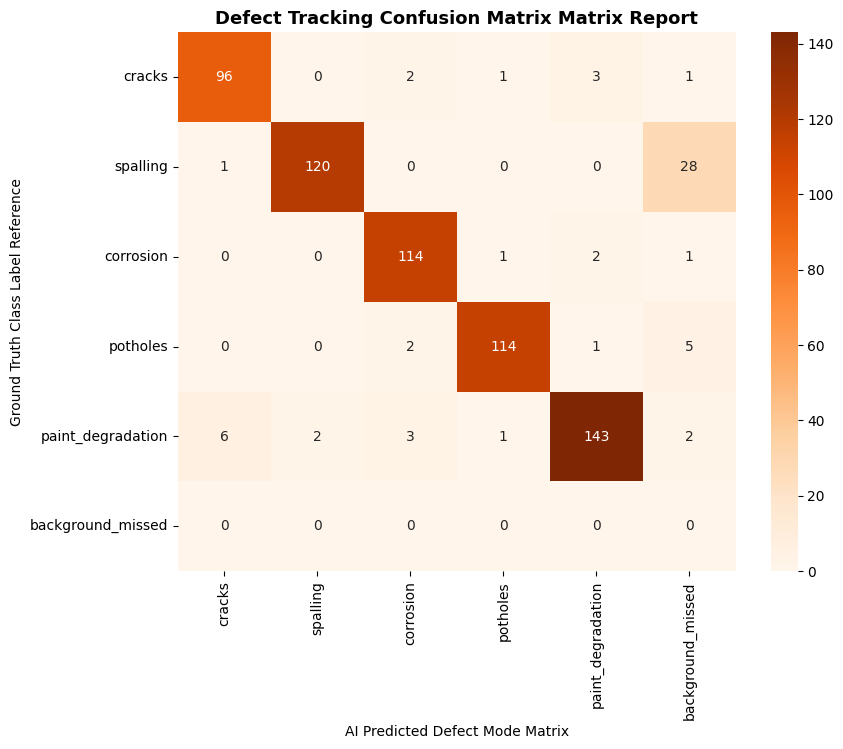

In [19]:
# --- HEATMAP CONFUSION MATRIX VISUALIZATION DISPLAY ENGINE ---
cm = sklearn_cm(all_gts, all_preds, labels=range(len(extended_labels[:len(set(all_gts) | set(all_preds))])))
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=extended_labels[:cm.shape[1]], yticklabels=extended_labels[:cm.shape[0]])
plt.title('Defect Tracking Confusion Matrix Matrix Report', fontweight='bold', fontsize=13)
plt.xlabel('AI Predicted Defect Mode Matrix')
plt.ylabel('Ground Truth Class Label Reference')
plt.savefig(str(OUTPUTS_DIR / 'confusion_matrix_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

🖼️ Displaying Error Analysis Grid Captures Isolated From High Confidence Deviations...


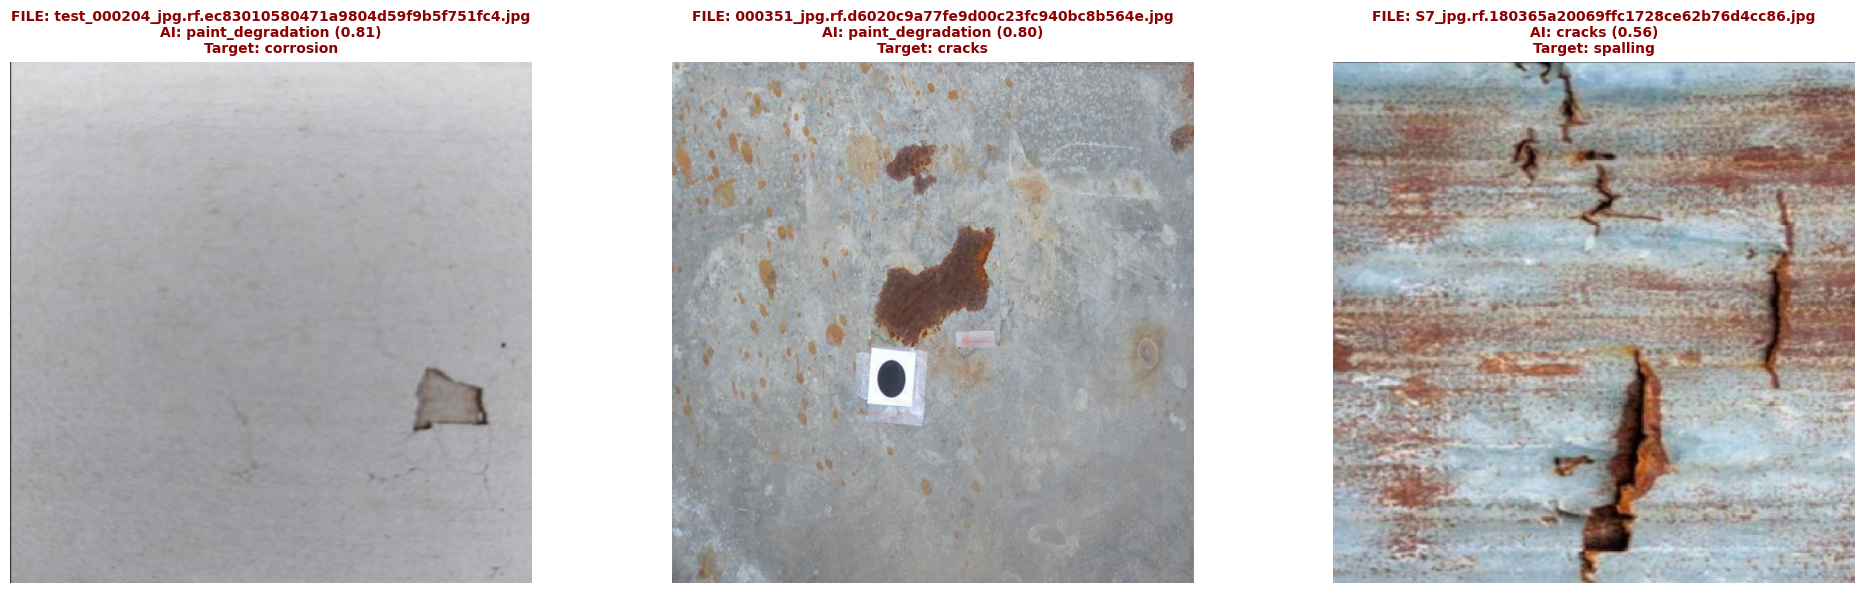

In [20]:
# --- ERROR ANALYSIS SCREENSHOT DISPLAY GRID ---
if error_samples:
    fig, axes = plt.subplots(1, min(len(error_samples), 3), figsize=(20, 6))
    if len(error_samples) == 1: axes = [axes]
    print(f"🖼️ Displaying Error Analysis Grid Captures Isolated From High Confidence Deviations...")
    for i, ax in enumerate(axes[:3]):
        err = error_samples[i]
        img_np = err['img'].permute(1, 2, 0).cpu().numpy()
        img_np = (img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]).clip(0, 1)
        ax.imshow(img_np)
        ax.set_title(f"FILE: {err['filename']}\nAI: {err['predicted']} ({err['confidence']:.2f})\nTarget: {err['actual']}", color='darkred', fontweight='bold', fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(str(OUTPUTS_DIR / 'error_analysis_grid.png'), dpi=300, bbox_inches='tight')
    plt.show()

In [21]:
live_effdet_m50 = history['map_50'][-1] if history['map_50'] else 0.0
live_effdet_m50_95 = history['map_50_95'][-1] if history['map_50_95'] else 0.0
live_effdet_miou = np.mean(iou_list) if iou_list else 0.0

performance_summary = pd.DataFrame([
    {
        'Model': 'EfficientDet-D0',
        'mAP@50': f"{live_effdet_m50:.4f}",
        'mAP@50-95': f"{live_effdet_m50_95:.4f}",
        'Precision': f"{macro_precision:.4f}",
        'Recall': f"{macro_recall:.4f}",
        'F1-Score': f"{macro_f1:.4f}",
        'mIoU': f"{live_effdet_miou:.4f}"
    }
])

print("\n" + "="*80)
print("EFFICIENTDET-D0 PERFORMANCE SUMMARY")
print("="*80)

print(performance_summary.to_markdown(index=False))



EFFICIENTDET-D0 PERFORMANCE SUMMARY
| Model           |   mAP@50 |   mAP@50-95 |   Precision |   Recall |   F1-Score |   mIoU |
|:----------------|---------:|------------:|------------:|---------:|-----------:|-------:|
| EfficientDet-D0 |   0.7311 |      0.4878 |      0.7986 |   0.7581 |     0.7767 | 0.6139 |
